# One-call 3-D maps and exporting a scene

- `quickmap(data, backend='3d')` builds a whole `Scene3D` from one call, dispatching by input: a **raster**
  becomes `terrain`, a **point** `FeatureCollection` a `point_cloud`, a **polygon** one `extruded_polygons`.
- A built scene exports via `save()` (suffix picks the format), `screenshot()` and `export_html()`.

Inputs are the **real Grand Canyon DEM** and the **real WorldPop population** vectorized with pyramids.

*DEM: Copernicus WorldDEM-30 © DLR/Airbus (EU/ESA). Population: WorldPop — CC-BY-4.0.*

---
*Data.* All layers below are built from **real data downloaded with
[earthlens](https://github.com/serapeum-org/earthlens)** and committed as small fixtures under
`examples/data/`; vector and 3-D layers are derived from those real rasters through **pyramids** (the GIS
engine), so nothing here is synthetic. Attributions are given per dataset.

In [1]:
%matplotlib inline
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import pyvista as pv

pv.OFF_SCREEN = True  # headless: every scene renders to an image, no interactive window

import pyramids  # import first: bootstraps pyramids' vendored GDAL
from pyramids.dataset import Dataset
from digitalearth.three_d import Scene3D

ROOT = Path.cwd()
while not (ROOT / 'examples' / 'data' / 'real_dem_mont_blanc.tif').exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
DATA = ROOT / 'examples' / 'data'


def show(scene, title=''):
    """Screenshot a Scene3D off-screen and show it inline, asserting the scene area is not blank."""
    img = scene.screenshot()
    bg = img[0, 0].astype(int)
    area = img[: int(img.shape[0] * 0.8)]
    content = (np.abs(area.astype(int) - bg).sum(-1) > 30).mean()
    assert content > 0.01, f'render looks blank: only {content:.1%} differs from the background'
    plt.figure(figsize=(6, 4)); plt.imshow(img); plt.axis('off')
    if title:
        plt.title(title)
    plt.show()


def show_image(img, title=''):
    """Show an already-captured RGB frame (e.g. from a pyvista Plotter) inline."""
    plt.figure(figsize=(7, 4)); plt.imshow(img); plt.axis('off')
    if title:
        plt.title(title)
    plt.show()
from digitalearth import quickmap
from pyramids.feature import FeatureCollection

## `quickmap(backend='3d')` — a raster becomes terrain

quickmap returned: Scene3D | layers: 1


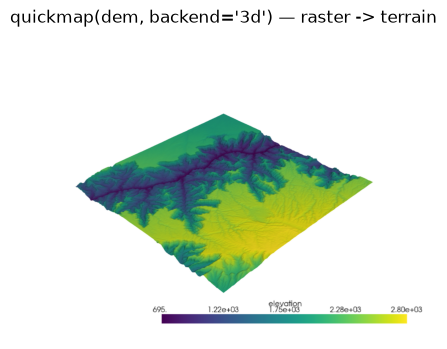

In [2]:
dem = Dataset.read_file(str(DATA / 'real_dem_grand_canyon.tif'))
scene = quickmap(dem, backend='3d')
print('quickmap returned:', type(scene).__name__, '| layers:', len(scene.layers))
scene.view('isometric')
show(scene, "quickmap(dem, backend='3d') — raster -> terrain")
scene.close()

## `quickmap(backend='3d')` — points become a point cloud, polygons extrude

The population raster, vectorized to points and to polygons, handed straight to `quickmap`.

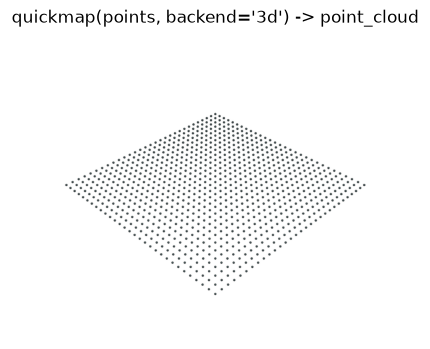

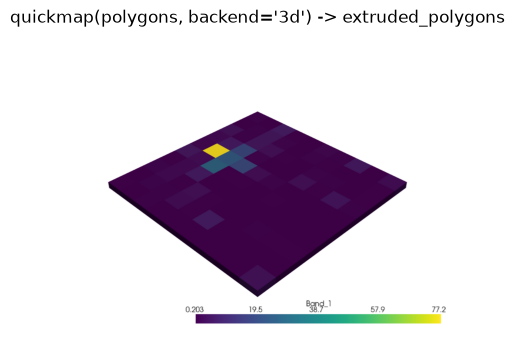

In [3]:
pop_path = DATA / 'real_population.tif'
# vectorize the real raster with pyramids, then wrap the GeoDataFrame as a pyramids FeatureCollection
pt_gdf = Dataset.read_file(str(pop_path)).resample(0.01, method='nearest neighbor')     .to_feature_collection(add_geometry='Point')
pt_fc = FeatureCollection(pt_gdf[pt_gdf['Band_1'] >= 0])
scene = quickmap(pt_fc, backend='3d', size=12.0)
scene.view('isometric')
show(scene, "quickmap(points, backend='3d') -> point_cloud")
scene.close()

poly_gdf = Dataset.read_file(str(pop_path)).resample(0.03, method='nearest neighbor')     .to_feature_collection(add_geometry='Polygon')
poly_fc = FeatureCollection(poly_gdf[poly_gdf['Band_1'] >= 0])
scene = quickmap(poly_fc, backend='3d', height=0.01, column='Band_1')
scene.view('isometric')
show(scene, "quickmap(polygons, backend='3d') -> extruded_polygons")
scene.close()

## Export — `save()`, `screenshot()`, `export_html()`

The suffix picks the writer: `.png` → screenshot, `.html` → interactive page, `.gltf` → a 3-D model.

In [4]:
import tempfile, os
tmp = Path(tempfile.mkdtemp())
dem = Dataset.read_file(str(DATA / 'real_dem_grand_canyon.tif'))
scene = Scene3D(off_screen=True)
scene.terrain(dem, z_exaggeration=2.0, cmap='terrain')

frame = scene.screenshot(str(tmp / 'terrain.png'))
html = scene.save(str(tmp / 'terrain.html'))
model = scene.save(str(tmp / 'terrain.gltf'))
print('screenshot array :', frame.shape)
print('png  bytes :', os.path.getsize(tmp / 'terrain.png'))
print('html bytes :', os.path.getsize(tmp / 'terrain.html'))
print('gltf bytes :', os.path.getsize(model))
scene.close()

C:\gdrive\algorithms\serapeum-github-org\repos\visualization\Digital-Earth\src\digitalearth\three_d\base.py:2138: UserWarning: Plotter contains non-PolyData datasets. These have been overwritten with PolyData surfaces and are internally copies of the original datasets.
  exporter(str(path), **kwargs)


screenshot array : (768, 1024, 3)
png  bytes : 192717
html bytes : 9240438
gltf bytes : 14637226
